In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
data = pd.read_csv('data.csv').to_numpy()
data = (data - data.mean(axis=1).reshape(-1, 1)) / data.std(axis=1).reshape(-1, 1)

In [4]:
train_length = round(len(data) * 0.8)

train_data = torch.tensor(data[:train_length], dtype=torch.float32)
test_data = torch.tensor(data[train_length:], dtype=torch.float32)
all_data = torch.tensor(data, dtype=torch.float32)

In [5]:
train_loader = DataLoader(TensorDataset(train_data), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(test_data), batch_size=16, shuffle=False)
all_loader = DataLoader(TensorDataset(all_data), batch_size=16, shuffle=True)

In [6]:
class GRUEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, encoding_size, num_layers):
        super(GRUEncoder, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True, num_layers=num_layers) # B x L x 2 * hid, 2 x B x hid
        self.enc = nn.Linear(hidden_size, encoding_size)

    def forward(self, x):
        x, h = self.gru(x)
        h = self.enc(h)
        return h

class GRUDecoder(nn.Module):
    def __init__(self, input_size, hidden_size, encoding_size, num_layers):
        super(GRUDecoder, self).__init__()
        self.enc = nn.Linear(encoding_size, hidden_size)
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True) # B x L x hid, 1 x B x hid
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.out = nn.Linear(hidden_size, input_size)

    def forward(self, h, seq_len=31):
        x = torch.zeros((h.shape[1], seq_len, h.shape[2]), device=h.device, requires_grad=True)
        h = self.enc(h)
        x, _ = self.gru(x, h)
        x = self.layer_norm(x)
        x = self.out(x)
        return x

class GRUAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, encoding_size, num_layers=1):
        super(GRUAutoencoder, self).__init__()
        self.encoder = GRUEncoder(input_size, hidden_size, encoding_size, num_layers)
        self.decoder = GRUDecoder(input_size, hidden_size, encoding_size, num_layers)
    def forward(self, x):
        h = self.encoder(x)
        x = self.decoder(h)
        return x

In [7]:
model = GRUAutoencoder(input_size=48, hidden_size=256, encoding_size=48, num_layers=1).to(device)

In [8]:
k = 0
for param in model.parameters():
    if param.requires_grad:
        k += torch.prod(torch.tensor(param.size()))
print(f'Model has {k} trainable parameters')

Model has 507744 trainable parameters


In [9]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

In [10]:
all_train_losses = []
train_losses = []
test_losses = []

In [ ]:
epochs = 200

for epoch in range(epochs):
    avg_loss = 0
    model.train()
    for batch in train_loader:
        batch = batch[0].view(-1, 31, 48).to(device)
        preds = model(batch)
        loss = criterion(preds, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        all_train_losses.append(loss.item())
        avg_loss += loss.item()
    avg_loss /= len(train_loader)
    print(f'Epoch {epoch + 1}, Loss: {avg_loss:.4f}')
    train_losses.append(avg_loss)
    
    model.eval()
    avg_test_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch[0].view(-1, 31, 48).to(device)
            preds = model(batch)
            loss = criterion(preds, batch)
            
            avg_test_loss += loss.item()
    avg_test_loss /= len(test_loader)
    test_losses.append(avg_test_loss)

    print(f'Test Loss: {avg_test_loss:.4f}')

In [13]:
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f'{name} grad: {param.grad.abs().mean()}')

encoder.gru.weight_ih_l0 grad: 0.00029972565243951976
encoder.gru.weight_hh_l0 grad: 9.805699664866552e-05
encoder.gru.bias_ih_l0 grad: 0.0004175861831754446
encoder.gru.bias_hh_l0 grad: 0.0003150685806758702
encoder.enc.weight grad: 0.0005780009087175131
encoder.enc.bias grad: 0.0013702074065804482
decoder.enc.weight grad: 0.0006127042579464614
decoder.enc.bias grad: 0.0007299644639715552
decoder.gru.weight_ih_l0 grad: 0.0
decoder.gru.weight_hh_l0 grad: 0.00023333795252256095
decoder.gru.bias_ih_l0 grad: 0.0007456173188984394
decoder.gru.bias_hh_l0 grad: 0.0006067465874366462
decoder.layer_norm.weight grad: 0.0006507819052785635
decoder.layer_norm.bias grad: 0.0004302923916839063
decoder.out.weight grad: 0.0021806349977850914
decoder.out.bias grad: 0.0016614689957350492


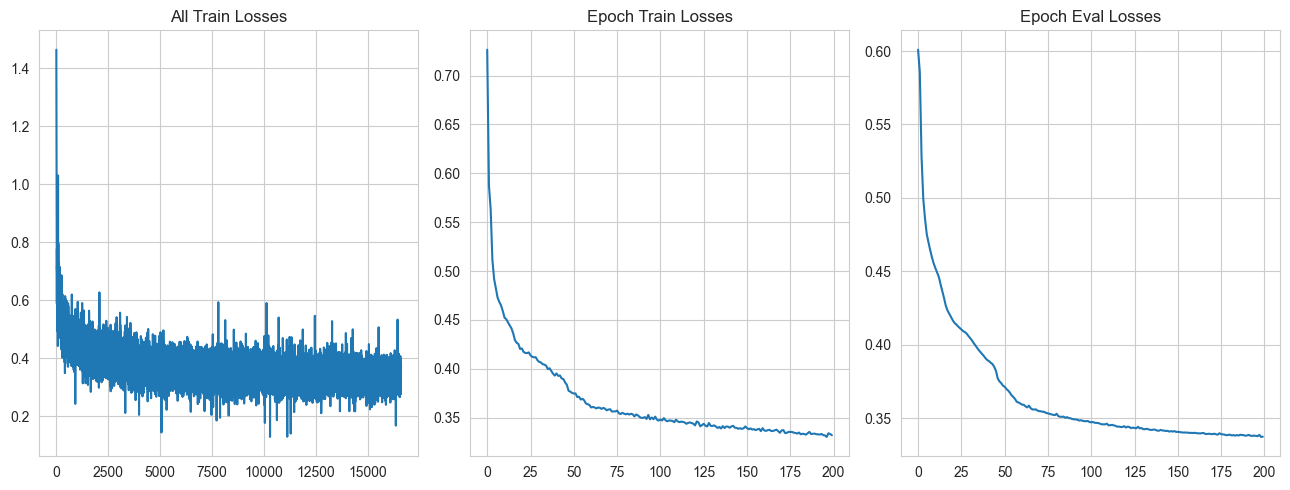

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].plot(all_train_losses)
axes[0].set_title('All Train Losses')
axes[1].plot(train_losses)
axes[1].set_title('Epoch Train Losses')
axes[2].plot(test_losses)
axes[2].set_title('Epoch Eval Losses')
plt.tight_layout()
plt.show()

In [11]:
model = GRUAutoencoder(input_size=48, hidden_size=256, encoding_size=48, num_layers=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

In [12]:
epochs = 150

for epoch in range(epochs):
    avg_loss = 0
    model.train()
    for batch in all_loader:
        batch = batch[0].view(-1, 31, 48).to(device)
        preds = model(batch)
        loss = criterion(preds, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item()
    avg_loss /= len(train_loader)
    print(f'Epoch {epoch + 1}, Loss: {avg_loss:.4f}')

Epoch 1, Loss: 0.7957
Epoch 2, Loss: 0.7218
Epoch 3, Loss: 0.6476
Epoch 4, Loss: 0.6165
Epoch 5, Loss: 0.5983
Epoch 6, Loss: 0.5824
Epoch 7, Loss: 0.5731
Epoch 8, Loss: 0.5656
Epoch 9, Loss: 0.5606
Epoch 10, Loss: 0.5559
Epoch 11, Loss: 0.5503
Epoch 12, Loss: 0.5423
Epoch 13, Loss: 0.5352
Epoch 14, Loss: 0.5293
Epoch 15, Loss: 0.5250
Epoch 16, Loss: 0.5214
Epoch 17, Loss: 0.5189
Epoch 18, Loss: 0.5166
Epoch 19, Loss: 0.5144
Epoch 20, Loss: 0.5123
Epoch 21, Loss: 0.5105
Epoch 22, Loss: 0.5086
Epoch 23, Loss: 0.5063
Epoch 24, Loss: 0.5043
Epoch 25, Loss: 0.5021
Epoch 26, Loss: 0.5010
Epoch 27, Loss: 0.4992
Epoch 28, Loss: 0.4970
Epoch 29, Loss: 0.4952
Epoch 30, Loss: 0.4934
Epoch 31, Loss: 0.4912
Epoch 32, Loss: 0.4891
Epoch 33, Loss: 0.4872
Epoch 34, Loss: 0.4845
Epoch 35, Loss: 0.4786
Epoch 36, Loss: 0.4732
Epoch 37, Loss: 0.4706
Epoch 38, Loss: 0.4681
Epoch 39, Loss: 0.4662
Epoch 40, Loss: 0.4638
Epoch 41, Loss: 0.4618
Epoch 42, Loss: 0.4599
Epoch 43, Loss: 0.4569
Epoch 44, Loss: 0.45

In [58]:
# torch.save(model.state_dict(), 'models/RAE.pt')

In [13]:
errors = []
encoded = []
reconstructed = []
with torch.no_grad():
    for sample in all_data:
        inputs = sample.view(-1, 31, 48).to(device)
        res = model(inputs).cpu().detach().flatten()
        reconstruction_error = criterion(res, sample)
        errors.append(reconstruction_error.cpu().detach().numpy())
        
        features = model.encoder(inputs).view(-1)
        encoded.append(features.cpu().detach().numpy())
        
        reconstructed.append(res.view(-1).cpu().detach().numpy())
errors = np.array(errors)
encoded = np.array(encoded)
reconstructed = np.array(reconstructed)

In [20]:
def plot_sample(sample):
    _, ax = plt.subplots(figsize=(20, 5))
    ax.plot(data[sample], label='True')
    pred_row = reconstructed[sample]
    ax.plot(pred_row, label='Predicted')
    mse = np.linalg.norm(data[sample] - pred_row) ** 2 / len(data[sample])
    ax.set_title(f'Model Prediction VS True Series, MSE: {mse.round(2)}, Sample: {sample}')
    plt.legend()
    plt.show()

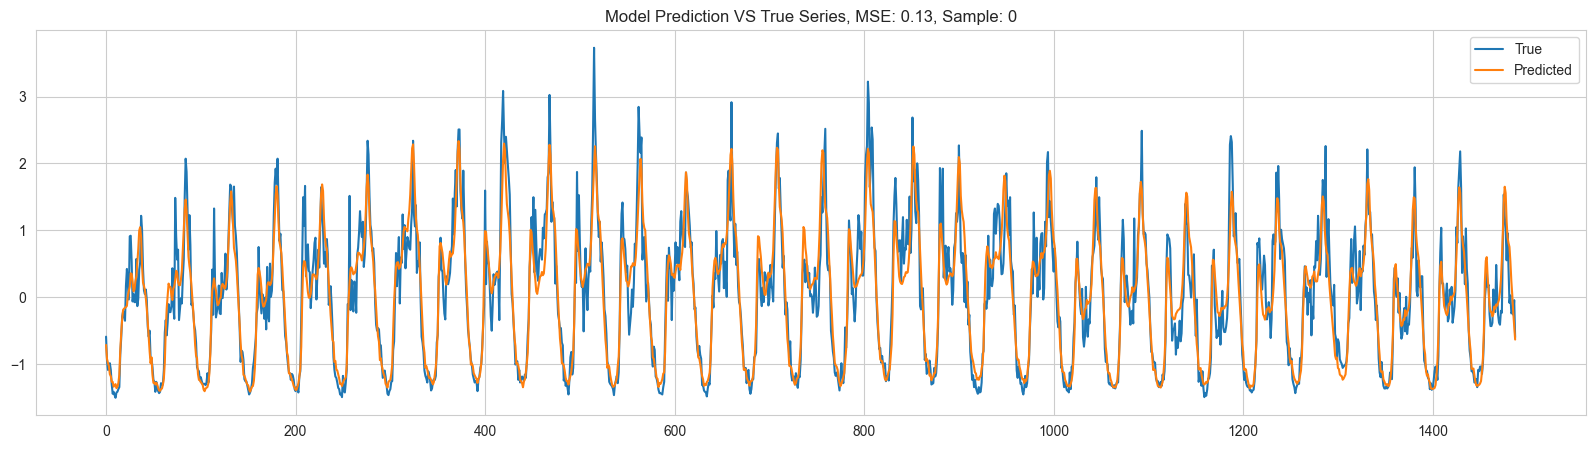

In [21]:
plot_sample(0)

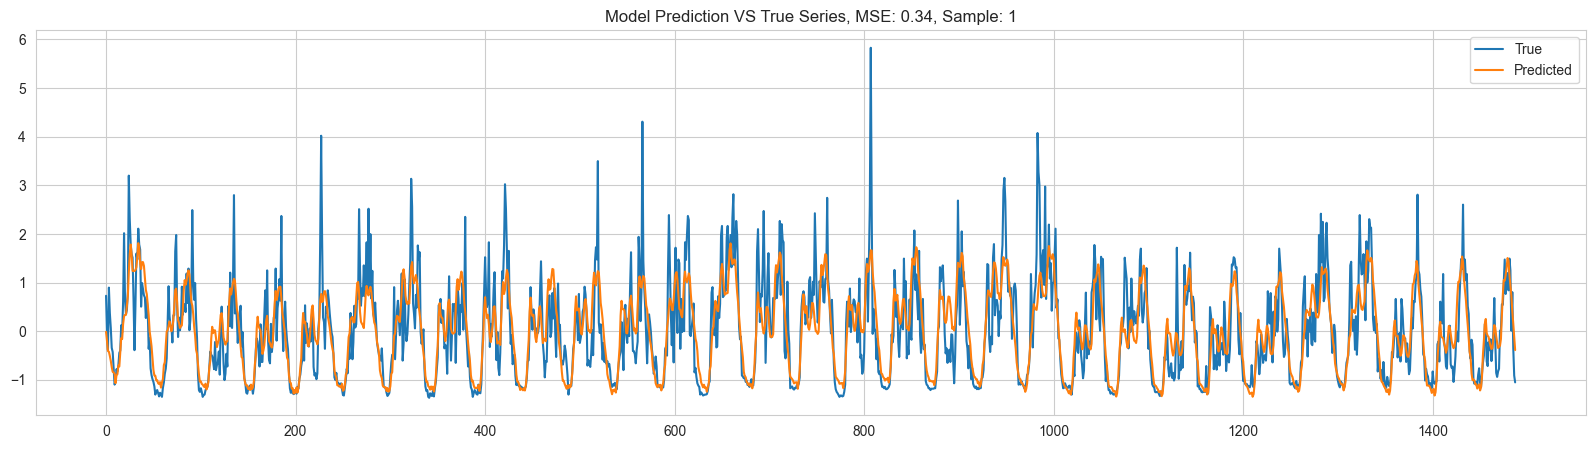

In [22]:
plot_sample(1)

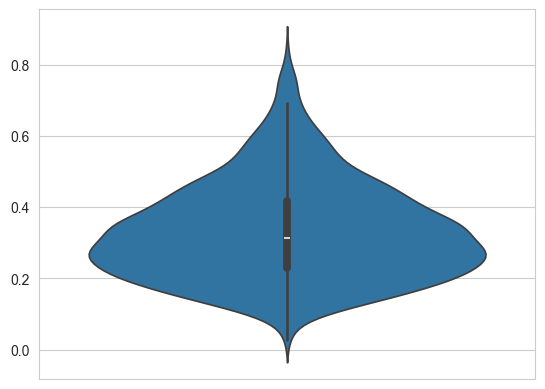

In [23]:
sns.violinplot(errors)
plt.show()

In [24]:
np.quantile(errors, 0.99)

0.7350809574127195

In [25]:
np.column_stack((np.argsort(-errors), -np.sort(-errors)))

array([[1.57800000e+03, 8.46119940e-01],
       [3.94000000e+02, 8.13452184e-01],
       [1.16800000e+03, 8.08595061e-01],
       ...,
       [1.10200000e+03, 4.27888297e-02],
       [6.54000000e+02, 3.00996155e-02],
       [2.23000000e+02, 2.79476214e-02]])

In [24]:
# 1578.0,0.846120
# 394.0,0.813452
# 1168.0,0.808595
# 122.0,0.783412
# 412.0,0.780540
# 142.0,0.776688
# 170.0,0.768401
# 950.0,0.765485
# 584.0,0.764036
# 1034.0,0.764018

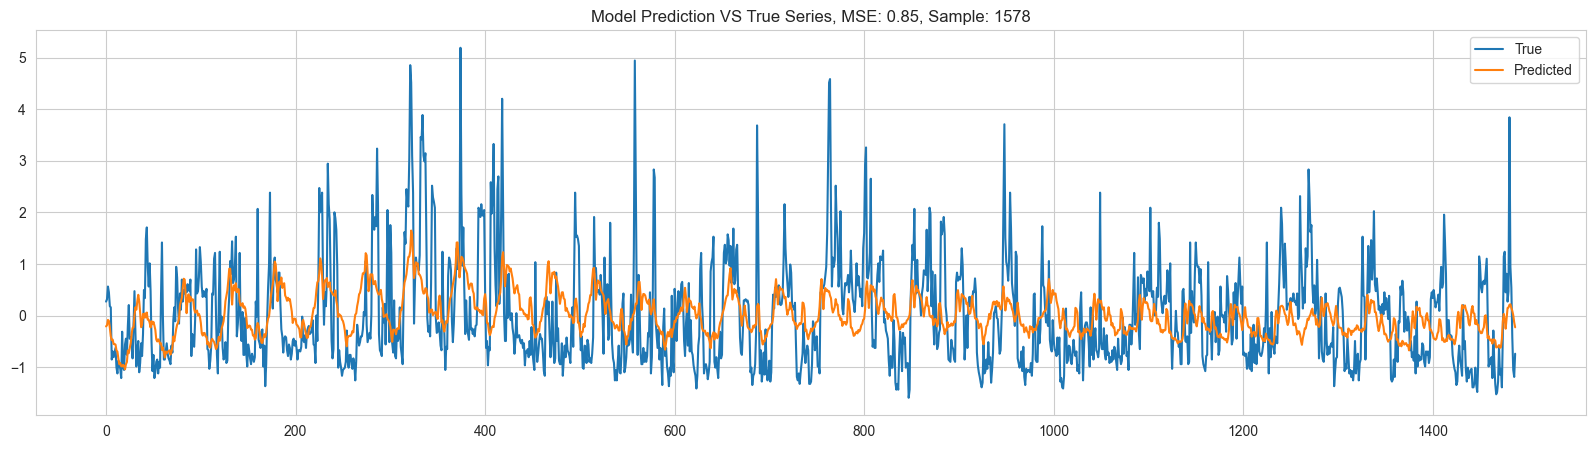

In [26]:
plot_sample(1578)

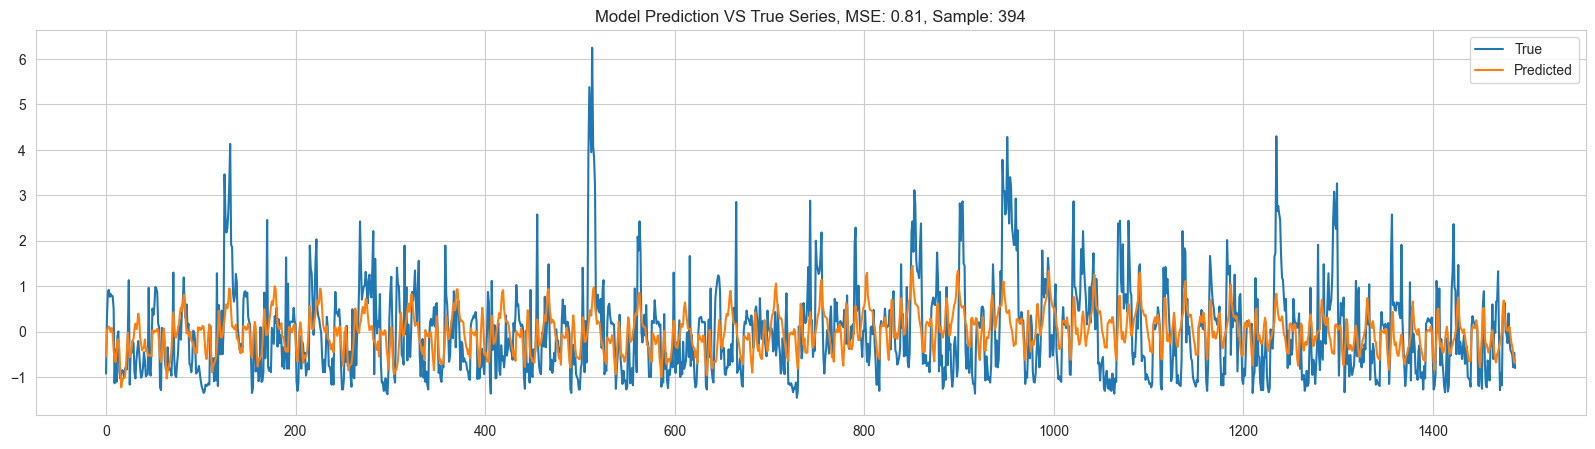

In [27]:
plot_sample(394)

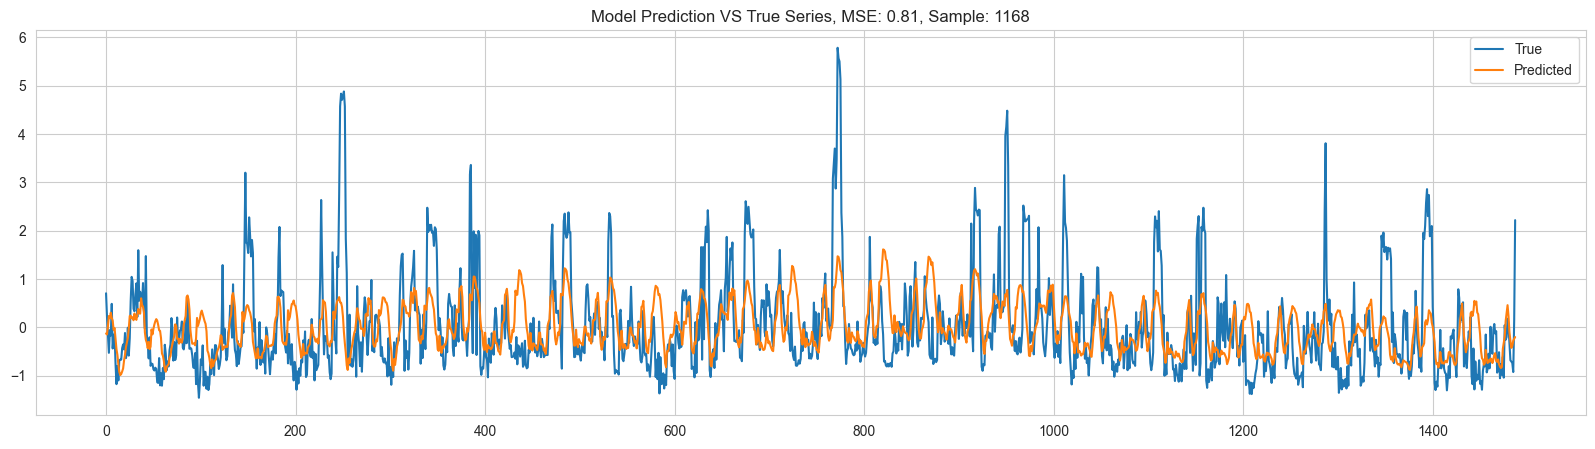

In [28]:
plot_sample(1168)

In [30]:
encoded_norm = (encoded - encoded.mean(axis=0)) / encoded.std(axis=0)

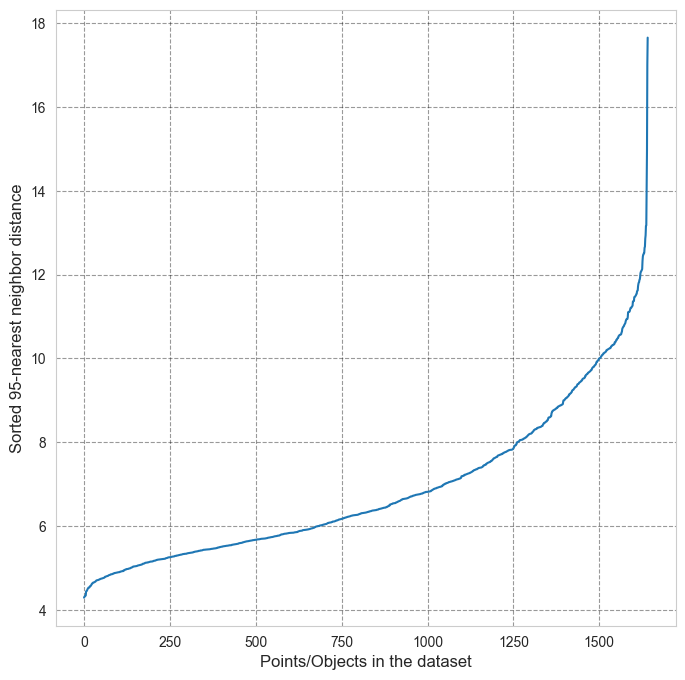

In [31]:
from sklearn.neighbors import NearestNeighbors


def get_kdist_plot(X=None, k=None, radius_nbrs=1.0):

    nbrs = NearestNeighbors(n_neighbors=k, radius=radius_nbrs).fit(X)

    # For each point, compute distances to its k-nearest neighbors
    distances, indices = nbrs.kneighbors(X) 
                                       
    distances = np.sort(distances, axis=0)
    distances = distances[:, k-1]

    # Plot the sorted K-nearest neighbor distance for each point in the dataset
    plt.figure(figsize=(8,8))
    plt.plot(distances)
    plt.xlabel('Points/Objects in the dataset', fontsize=12)
    plt.ylabel('Sorted {}-nearest neighbor distance'.format(k), fontsize=12)
    plt.grid(True, linestyle="--", color='black', alpha=0.4)
    plt.show()
    plt.close()


k = 2 * encoded_norm.shape[-1] - 1 # k=2*{dim(dataset)} - 1
get_kdist_plot(X=encoded_norm, k=k)

In [46]:
from sklearn.cluster import DBSCAN

# Создаем объект DBSCAN
dbscan = DBSCAN(eps=9.35, min_samples=15)

# Проводим кластеризацию данных
clusters = dbscan.fit_predict(encoded_norm)

# Ищем объекты, отнесенные к кластеру -1 (это аномалии)
anomalies_indices = np.where(clusters == -1)[0]
anomalies_indices

# 1168, 1178, 1633

array([  28,  528,  677,  921,  936, 1014, 1189, 1233, 1486, 1508],
      dtype=int64)

In [35]:
# 28,  528,  677,  921,  936, 1014, 1189, 1233, 1486, 1508
# 528, 1014, 1486

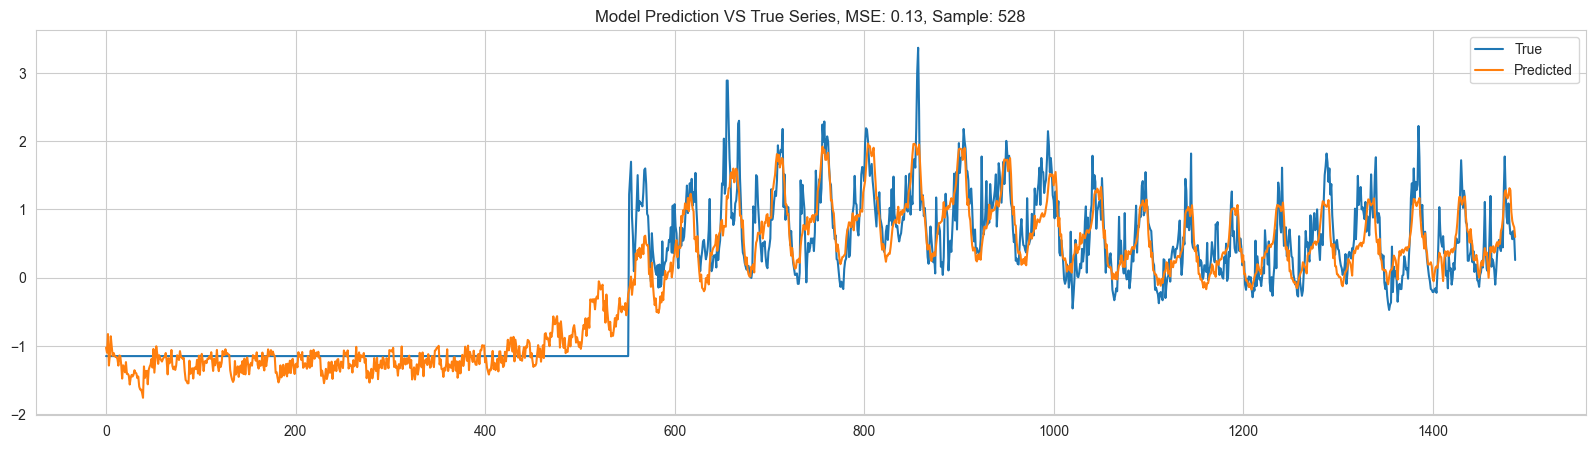

In [47]:
plot_sample(528)

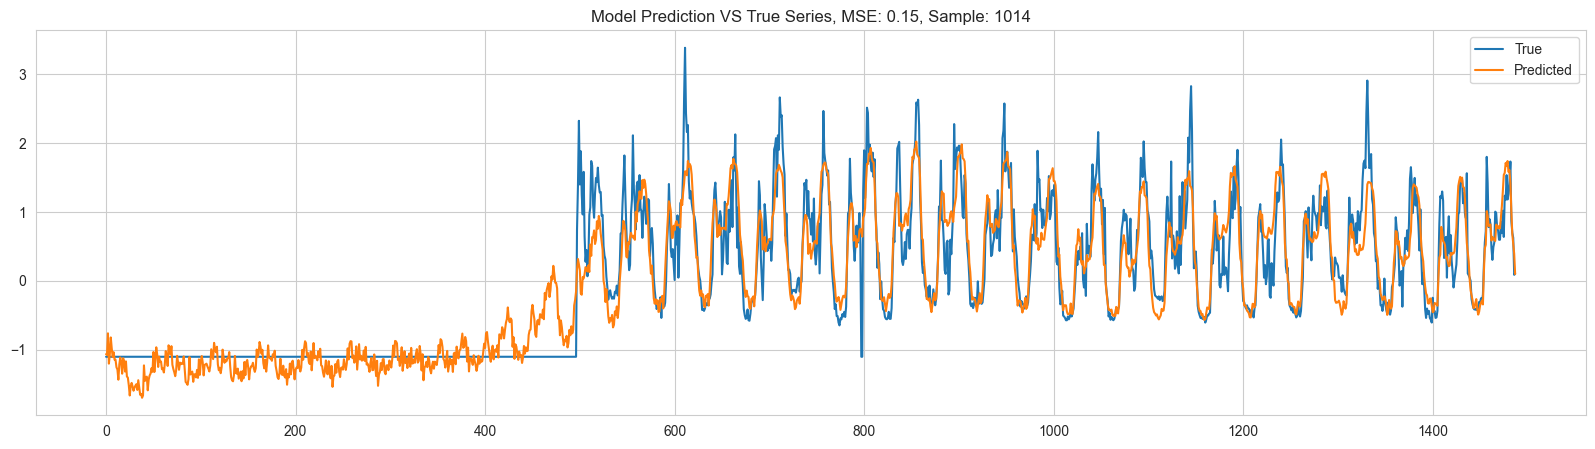

In [48]:
plot_sample(1014)

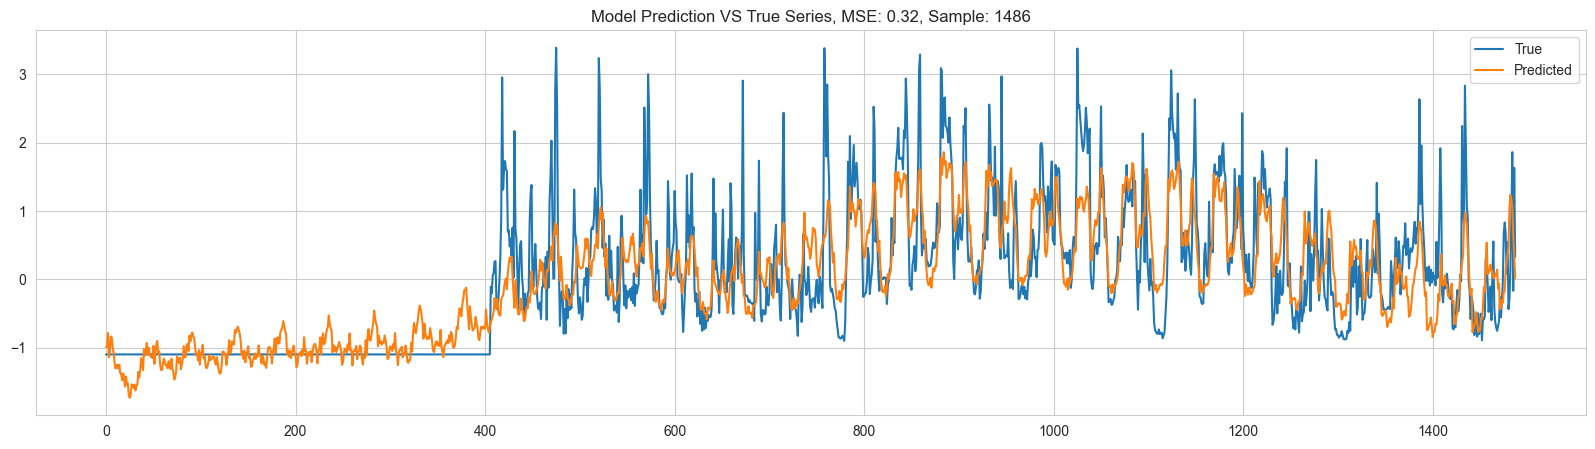

In [49]:
plot_sample(1486)

In [15]:
import matplotlib

size = 15
matplotlib.rc('font', size=size)
matplotlib.rc('axes', titlesize=size)

In [50]:
medians = np.median(encoded_norm, axis=0)
middle = np.repeat(np.inf, 4)
cur_min = np.inf
for sample in encoded_norm:
    dist = np.dot(sample - medians, sample - medians)
    if dist < cur_min:
        cur_min = dist
        middle = sample
q = 0.001
dists = np.linalg.norm(encoded_norm - middle, axis=1)
band = max(np.quantile(dists, q), 1e-3)
band

3.060841447591782

In [52]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(kernel='gaussian', bandwidth=band)
kde.fit(encoded_norm)
kde_scores = kde.score_samples(encoded_norm)
min_max = 1 - (kde_scores - kde_scores.min()) / (kde_scores.max() - kde_scores.min())

<Axes: >

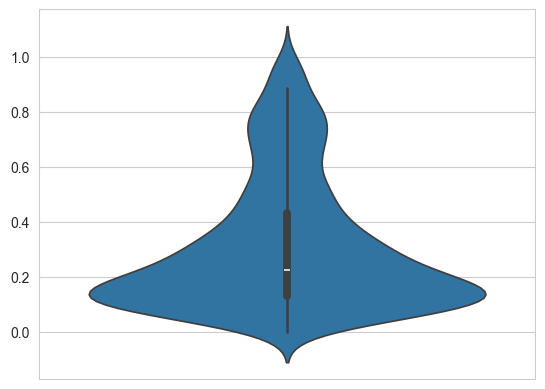

In [53]:
sns.violinplot(min_max)

In [54]:
np.vstack((-np.sort(-min_max), np.argsort(-min_max))).T

array([[1.00000000e+00, 9.36000000e+02],
       [9.97737057e-01, 1.48600000e+03],
       [9.95803932e-01, 4.62000000e+02],
       ...,
       [8.97765850e-03, 1.58000000e+02],
       [7.32062655e-03, 8.29000000e+02],
       [0.00000000e+00, 1.13400000e+03]])

In [ ]:
# 1.000000,936.0
# 0.997737,1486.0
# 0.995804,462.0
# 0.993498,28.0
# 0.991656,921.0
# 0.987900,1018.0
# 0.986724,1189.0
# 0.984253,647.0
# 0.979110,582.0
# 0.978009,1233.0

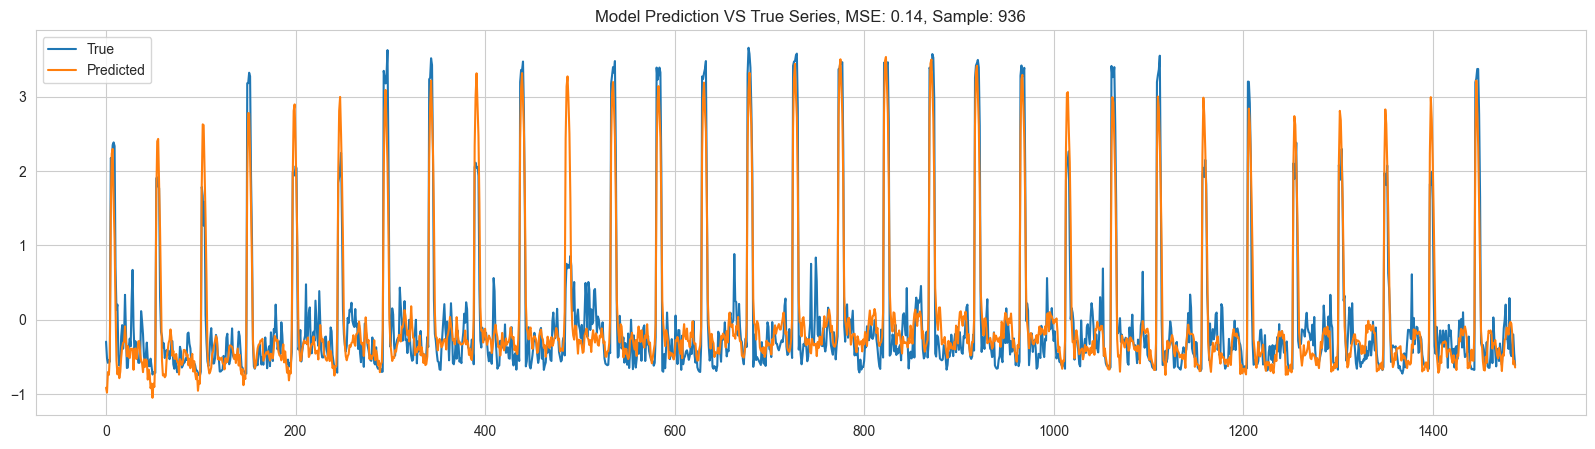

In [55]:
plot_sample(936)

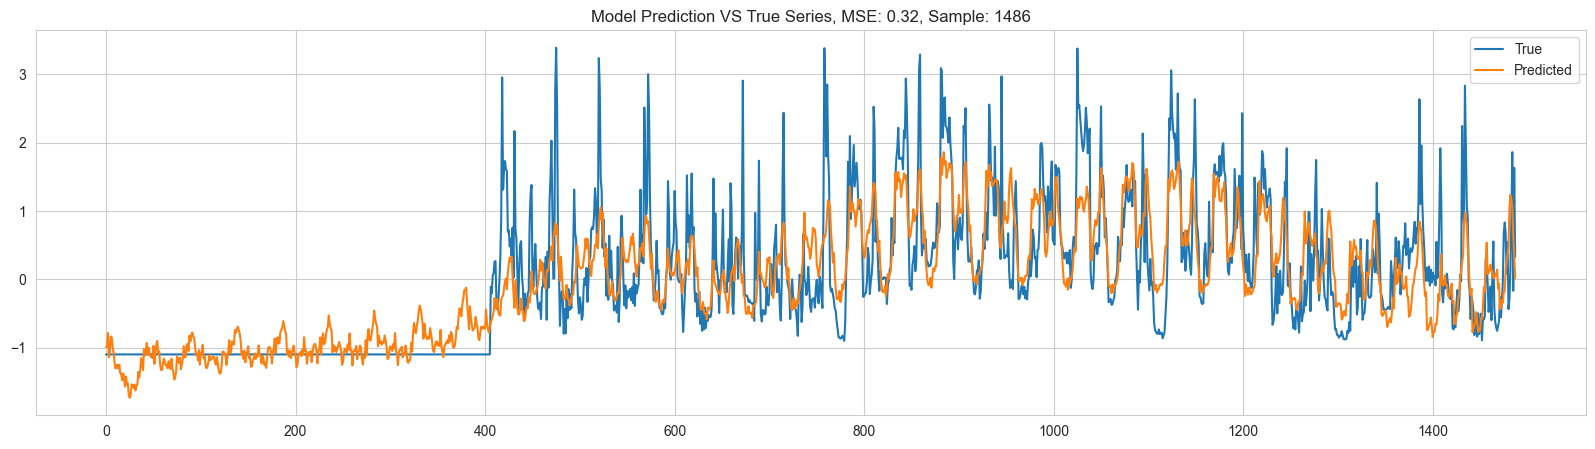

In [56]:
plot_sample(1486)

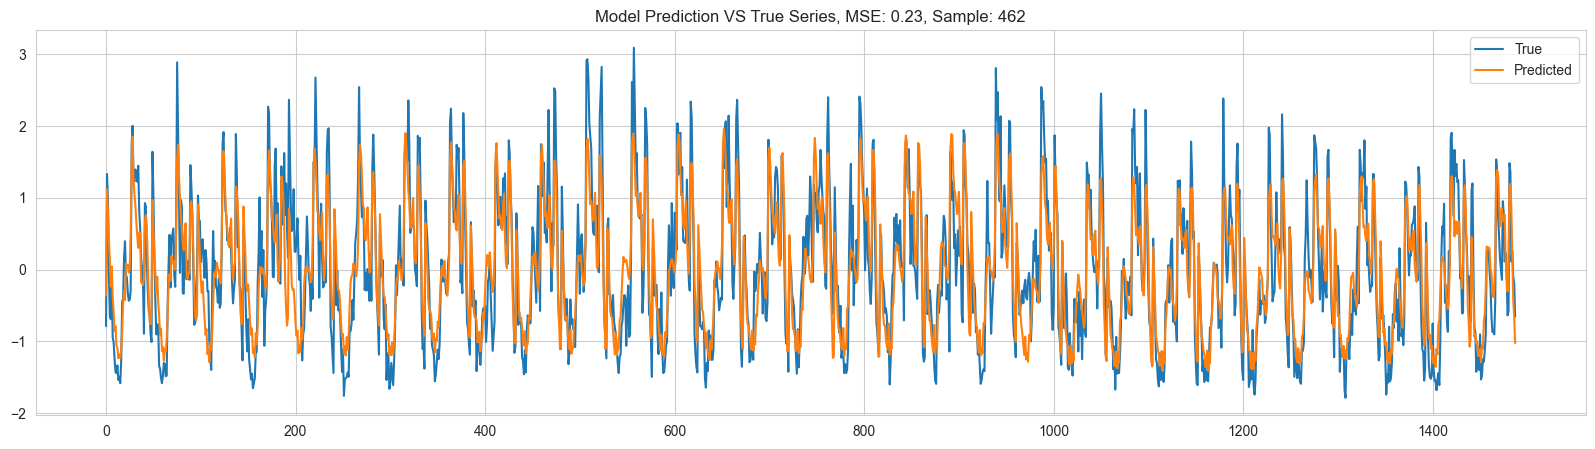

In [57]:
plot_sample(462)